## TIFF plot

In [ ]:
# Settings + Data fetching
system("conda install -y conda-forge::r-rcpp conda-forge::openssl conda-forge::r-sf conda-forge::r-terra conda-forge::r-ncdf4")
system("conda install -y conda-forge::r-r.utils conda-forge::r-tidyverse conda-forge::libgdal-hdf5 conda-forge::r-ggplot2")

# GET THE DEFAULT INITIAL PARAMETERS

## CONDA ENVIRONEMENT (OPTIONAL)
# Sys.getenv("CONDA_DEFAULT_ENV")
## VERSION OF R IN USE
# version # Check the version

Warning message in system("conda install -y conda-forge::r-rcpp conda-forge::openssl conda-forge::r-sf \n       conda-forge::r-terra conda-forge::r-ncdf4 conda-forge::r-r.utils conda-forge::r-tidyverse \n       conda-forge::libgdal-hdf5"):
“error in running command”


               _                           
platform       x86_64-conda-linux-gnu      
arch           x86_64                      
os             linux-gnu                   
system         x86_64, linux-gnu           
status                                     
major          4                           
minor          5.2                         
year           2025                        
month          10                          
day            31                          
svn rev        88974                       
language       R                           
version.string R version 4.5.2 (2025-10-31)
nickname       [Not] Part in a Rumble      

In [ ]:
# install.packages("ncdf4", "tidyverse", "terra", "dplyr", "sf", "jsonlite", "utils")
install.packages("ncdf4")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [ ]:
library(ncdf4)
library(R.utils)
library(tidyverse) # because who can live without the tidyverse?
library(terra)     
library(dplyr)
library(sf)        
library(jsonlite) 
library(utils)
library(ggplot2)

Loading required package: R.oo

Loading required package: R.methodsS3

R.methodsS3 v1.8.2 (2022-06-13 22:00:14 UTC) successfully loaded. See ?R.methodsS3 for help.

R.oo v1.27.1 (2025-05-02 21:00:05 UTC) successfully loaded. See ?R.oo for help.


Attaching package: ‘R.oo’


The following object is masked from ‘package:R.methodsS3’:

    throw


The following objects are masked from ‘package:methods’:

    getClasses, getMethods


The following objects are masked from ‘package:base’:

    attach, detach, load, save


R.utils v2.13.0 (2025-02-24 21:20:02 UTC) successfully loaded. See ?R.utils for help.


Attaching package: ‘R.utils’


The following object is masked from ‘package:utils’:

    timestamp


The following objects are masked from ‘package:base’:

    cat, commandArgs, getOption, isOpen, nullfile, parse, use, warnings


Warning message:
“package ‘ggplot2’ was built under R version 4.5.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr   

In [ ]:
global_topo_tiff_gz <- "global_topo.tiff.gz"

# nchar(global_topo_tiff)
filename.length <- nchar(global_topo_tiff_gz)

# Get the extension ("." + 2 letters)
substr(global_topo_tiff_gz,filename.length-2, filename.length)

# Get the name without the extension ("." + 2 letters)
start <- 1
end <- filename.length-3
global_topo_tiff <- substr(global_topo_tiff_gz,start, end)

print(global_topo_tiff_gz)
print(global_topo_tiff)

# ==============================================================================

if(!file.exists(global_topo_tiff_gz)){
    download.file("https://topex.ucsd.edu/pub/global_topo_tiff/global.tiff.gz", global_topo_tiff_gz, mode = "wb")
}

# ==============================================================================
# UNZIP FILENAME
# ==============================================================================

if(!file.exists(global_topo_tiff)){
    R.utils::gunzip(global_topo_tiff_gz, overwrite=FALSE, remove=TRUE, BFR.SIZE=1e+07)
}

[1] ".gz"

[1] "global_topo.tiff.gz"
[1] "global_topo.tiff"


In [ ]:
# ==============================================================================
# FILE INFO
# ==============================================================================
print(file.info( substr(global_topo_tiff_gz,start, end) ))
print(file.info( substr(global_topo_tiff,start, end) ))

ls()

                     size isdir mode               mtime               ctime
global_topo.tiff 27104274 FALSE  644 2026-04-28 07:36:52 2026-04-28 07:36:52
                               atime uid gid  uname grname
global_topo.tiff 2026-04-28 07:36:52 999 100 jovyan  users
                     size isdir mode               mtime               ctime
global_topo.tiff 27104274 FALSE  644 2026-04-28 07:36:52 2026-04-28 07:36:52
                               atime uid gid  uname grname
global_topo.tiff 2026-04-28 07:36:52 999 100 jovyan  users


[1] "end"                 "filename.length"     "global_topo_tiff"   
[4] "global_topo_tiff_gz" "start"

## NetCDF (Copernicus Data Files)

In [ ]:
system("conda install -y conda-forge::r-lubridate conda-forge::r-rcolorbrewer conda-forge::r-lattice conda-forge::r-png")

In [ ]:
library(ncdf4) #     ncdf4: open, write and create NetCDF files (also provides metadata information)
library(lubridate) # lubridate: operate on date and times data
library(RColorBrewer) # RColorBrewer: create colour palettes for thematic maps
library(lattice) # lattice : visualization system for typical graphics

In [ ]:
# 2.2 DOWNLOAD AND LOAD BATHYMETRY ----
bathy_file <- "global_topo_1min_topo_19_1.nc"
if(!file.exists(bathy_file)){
    download.file("https://topex.ucsd.edu/pub/global_topo_1min/topo_19.1.nc", bathy_file, mode = "wb")
}

print('File Downloaded')
Bathy <- rast(bathy_file)
print("Converted into Raster File")

[1] "File Downloaded"


Warning message:
“[rast] unknown extent”


[1] "Converted into Raster File"


In [ ]:
Bathy

class       : SpatRaster 
size        : 9600, 21600, 1  (nrow, ncol, nlyr)
resolution  : 1, 1  (x, y)
extent      : 0, 21600, 0, 9600  (xmin, xmax, ymin, ymax)
coord. ref. :  
source      : global_topo_1min_topo_19_1.nc 
name        : global_topo_1min_topo_19_1 

### Plots

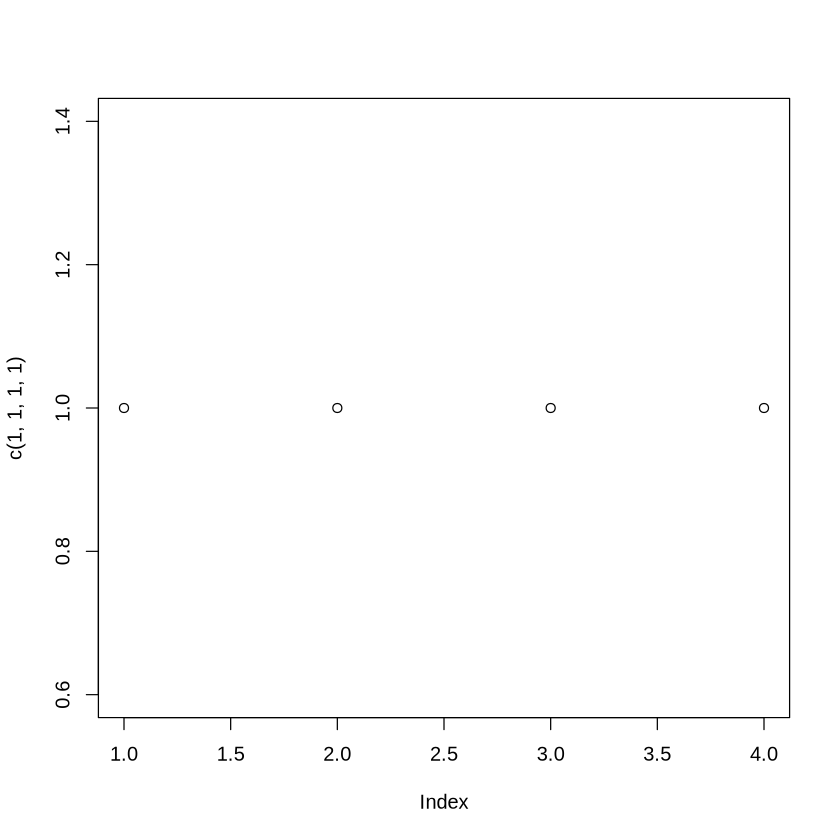

In [ ]:
plot(c(1,1,1,1))

In [ ]:
# ==============================================================================
# 3. MAP PLOTTING ----
# ==============================================================================
png <- 1
if (png) {
  png(filename = "outputs/Fig1.png", width = 1080, height = 720)
    
} else {
  pdf("outputs/Fig1.pdf")
}

Depth_cuts <- c(-8200 ,-7000 ,-6000 ,-5000, -4000, -3000, -1800, -1400, -1000,  -600,  -400 , -200  ,   0 ,   50  , 250   ,500)
Depth_cols <- c(
  "#D6EAF8", "#AED6F1", "#85C1E9", "#5DADE2", "#3498DB",
  "#5DADE2", "#85C1E9", "#A9CCE3", "#D4E6F1", "#EBF5FB",
  "#F4F6F7", "#F8F9F9", "#FDFEFE", "#F2F3F4", "#EAEDED"
)

# Plot bathymetry
plot(Bathy,breaks = Depth_cuts, col = Depth_cols, legend = FALSE, axes = FALSE, box = FALSE,mar=c(0,0,0,0))

# Save the plot ---
dev.off()


agg_record_1028503186 
                    2

## Data Exploration

In [ ]:
## A.1 First Five Rows of Data Frame 
head(Bathy,5)

,global_topo_1min_topo_19_1
,<dbl>
1,-1539.120
2,-1538.341
3,-1539.416
4,-1540.569
5,-1540.435


In [ ]:
## A.2 Column Names of Data Frame
names(Bathy)

## A.3 Number of Rows & Columns of Data Frame
dim(Bathy)

## A.4 Structure of Data Frame Columns
str(Bathy)

[1] "global_topo_1min_topo_19_1"

In [ ]:
## A.5 Descriptive Statistics Using summary()
summary(Bathy)

Warning message:
“[summary] used a sample”


 global_topo_1min_topo_19_1
 Min.   :-10775.9          
 1st Qu.: -4408.5          
 Median : -2818.9          
 Mean   : -2109.6          
 3rd Qu.:   136.3          
 Max.   :  6110.8          

In [ ]:
## A.6 Count NA Values 
colSums(is.na(Bathy))                 # Count missing values

global_topo_1min_topo_19_1
0
0
0
0
0
0
0
0
0
0


In [ ]:
## A.7 Draw Pairs Plot of Data Frame Columns
'install.packages("GGally")             # Install GGally package
library("GGally")                      # Load GGally package'

# ggpairs(Bathy)                        # Draw pairs plot

[1] "install.packages(\"GGally\")             # Install GGally package\nlibrary(\"GGally\")                      # Load GGally package"

In [ ]:
## A.8 Boxplots of Multiple Columns 
# ggplot(as.data.frame(Bathy),                    # Draw boxplots
#        aes(x = value,
#            fill = name)) +
#   geom_boxplot()

ERROR while rich displaying an object: Error in `geom_boxplot()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 1st layer.
Caused by error:
! object 'value' not found

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 

In [ ]:
## A.9 Histograms of Multiple Columns 
# ggplot(Bathy,                    # Draw histograms
#        aes(x = value)) +
#   geom_histogram() + 
#   facet_wrap(name ~ ., scales = "free")

ERROR: [1m[33mError[39m in `fortify()`:[22m
[1m[22m[33m![39m `data` must be a [34m<data.frame>[39m, or an object coercible by `fortify()`,
  or a valid [34m<data.frame>[39m-like object coercible by `as.data.frame()`.
[1mCaused by error in `check_data_frame_like()`:[22m
[1m[22m[33m![39m `dim(data)` must return an [34m<integer>[39m of length 2.


In [ ]:
# Open the NetCDF file

nc_file <- nc_open(bathy_file)
print(nc_file)

# Structure of the file

names(nc_file)
# Names of the variables
names(nc_file$var)
# Names of the dimensions
names(nc_file$dim)

File global_topo_1min_topo_19_1.nc (NC_FORMAT_NETCDF4):

     1 variables (excluding dimension variables):
        float z[lon,lat]   (Chunking: [129,128])  (Compression: shuffle,level 3)
            long_name: z
            _FillValue: NaN
            actual_range: -10926.9326171875
             actual_range: 8516.9990234375

     2 dimensions:
        lon  Size:21600 
            long_name: longitude
            units: degrees_east
            actual_range: -180
             actual_range: 180
        lat  Size:9600 
            long_name: latitude
            units: degrees_north
            actual_range: -80
             actual_range: 80

    6 global attributes:
        Conventions: COARDS, CF-1.5
        title: 
        history: grdsample -R-180/180/-80/80 -I1m @GMTAPI@-000001 -Gtopo_19.1.nc -fg --GMT_HISTORY=false
        description: 
        GMT_version: 5.4.5 [64-bit]
        node_offset: 1


[1] "filename"    "writable"    "id"          "error"       "safemode"   
 [6] "format"      "is_GMT"      "groups"      "fqgn2Rindex" "ndims"      
[11] "natts"       "dim"         "unlimdimid"  "nvars"       "var"

[1] "z"

[1] "lon" "lat"

In [ ]:
# List the attributes and sub-attributes

i <- 1
for(listVar in names(nc_file)){
    cat(i, listVar,"\n")
    for(listNames in names(nc_file[[listVar]])){
        cat("Attr:", listNames, "---", names(nc_file[[listVar]][[listNames]]),"\n")
    }
    i <- i + 1
}

## TIFF plot

In [ ]:
# Settings + Data fetching
system("conda install -y conda-forge::r-rcpp conda-forge::openssl conda-forge::r-sf conda-forge::r-terra conda-forge::r-ncdf4")
system("conda install -y conda-forge::r-r.utils conda-forge::r-tidyverse conda-forge::libgdal-hdf5 conda-forge::r-ggplot2")

# install.packages("ncdf4", "tidyverse", "terra", "dplyr", "sf", "jsonlite", "utils")
# install.packages("ncdf4")

# GET THE DEFAULT INITIAL PARAMETERS

## CONDA ENVIRONEMENT (OPTIONAL)
Sys.getenv("CONDA_DEFAULT_ENV")
## VERSION OF R IN USE
version

system("conda activate")

[1] "base"

               _                           
platform       x86_64-conda-linux-gnu      
arch           x86_64                      
os             linux-gnu                   
system         x86_64, linux-gnu           
status                                     
major          4                           
minor          5.2                         
year           2025                        
month          10                          
day            31                          
svn rev        88974                       
language       R                           
version.string R version 4.5.2 (2025-10-31)
nickname       [Not] Part in a Rumble      

In [ ]:
library(ncdf4)
library(R.utils)
library(tidyverse) # because who can live without the tidyverse?
library(terra)     
library(dplyr)
library(sf)        
library(jsonlite) 
library(utils)
library(ggplot2)

Loading required package: R.oo

Loading required package: R.methodsS3

R.methodsS3 v1.8.2 (2022-06-13 22:00:14 UTC) successfully loaded. See ?R.methodsS3 for help.

R.oo v1.27.1 (2025-05-02 21:00:05 UTC) successfully loaded. See ?R.oo for help.


Attaching package: ‘R.oo’


The following object is masked from ‘package:R.methodsS3’:

    throw


The following objects are masked from ‘package:methods’:

    getClasses, getMethods


The following objects are masked from ‘package:base’:

    attach, detach, load, save


R.utils v2.13.0 (2025-02-24 21:20:02 UTC) successfully loaded. See ?R.utils for help.


Attaching package: ‘R.utils’


The following object is masked from ‘package:utils’:

    timestamp


The following objects are masked from ‘package:base’:

    cat, commandArgs, getOption, isOpen, nullfile, parse, use, warnings


Warning message:
“package ‘ggplot2’ was built under R version 4.5.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr   

In [ ]:
global_topo_tiff_gz <- "global_topo.tiff.gz"

# nchar(global_topo_tiff)
filename.length <- nchar(global_topo_tiff_gz)

# Get the extension ("." + 2 letters)
substr(global_topo_tiff_gz,filename.length-2, filename.length)

# Get the name without the extension ("." + 2 letters)
start <- 1
end <- filename.length-3
global_topo_tiff <- substr(global_topo_tiff_gz,start, end)

print(global_topo_tiff_gz)
print(global_topo_tiff)

# ==============================================================================

if(!file.exists(global_topo_tiff_gz)){
    download.file("https://topex.ucsd.edu/pub/global_topo_tiff/global.tiff.gz", global_topo_tiff_gz, mode = "wb")
}

# ==============================================================================
# UNZIP FILENAME
# ==============================================================================

if(!file.exists(global_topo_tiff)){
    R.utils::gunzip(global_topo_tiff_gz, overwrite=FALSE, remove=TRUE, BFR.SIZE=1e+07)
}

[1] ".gz"

[1] "global_topo.tiff.gz"
[1] "global_topo.tiff"


In [ ]:
# ==============================================================================
# FILE INFO
# ==============================================================================
print(file.info( substr(global_topo_tiff_gz,start, end) ))
print(file.info( substr(global_topo_tiff,start, end) ))

ls()

                     size isdir mode               mtime               ctime
global_topo.tiff 27104274 FALSE  644 2026-04-30 07:14:22 2026-04-30 07:14:22
                               atime uid gid  uname grname
global_topo.tiff 2026-04-30 07:14:22 999 100 jovyan  users
                     size isdir mode               mtime               ctime
global_topo.tiff 27104274 FALSE  644 2026-04-30 07:14:22 2026-04-30 07:14:22
                               atime uid gid  uname grname
global_topo.tiff 2026-04-30 07:14:22 999 100 jovyan  users


[1] "end"                 "filename.length"     "global_topo_tiff"   
[4] "global_topo_tiff_gz" "start"

## NetCDF (Copernicus Data Files)

In [ ]:
system("conda install -y conda-forge::r-lubridate conda-forge::r-rcolorbrewer conda-forge::r-lattice conda-forge::r-png")

In [ ]:
library(ncdf4) #     ncdf4: open, write and create NetCDF files (also provides metadata information)
library(lubridate) # lubridate: operate on date and times data
library(RColorBrewer) # RColorBrewer: create colour palettes for thematic maps
library(lattice) # lattice : visualization system for typical graphics

In [ ]:
# 2.2 DOWNLOAD AND LOAD BATHYMETRY ----
bathy_file <- "global_topo_1min_topo_19_1.nc"
download.file("https://topex.ucsd.edu/pub/global_topo_1min/topo_19.1.nc", bathy_file, mode = "wb")

print('File Downloaded')
Bathy <- rast(bathy_file)
print("Converted into Raster File")

[1] "File Downloaded"


Warning message:
“[rast] unknown extent”


[1] "Converted into Raster File"


### Plots

In [ ]:
# ==============================================================================
# 3. MAP PLOTTING ----
# ==============================================================================
png <- 1
if (png) {
  png(filename = "outputs/Fig1.png", width = 1080, height = 720)
    
} else {
  pdf("outputs/Fig1.pdf")
}

Depth_cuts <- c(-8200 ,-7000 ,-6000 ,-5000, -4000, -3000, -1800, -1400, -1000,  -600,  -400 , -200  ,   0 ,   50  , 250   ,500)
Depth_cols <- c(
  "#D6EAF8", "#AED6F1", "#85C1E9", "#5DADE2", "#3498DB",
  "#5DADE2", "#85C1E9", "#A9CCE3", "#D4E6F1", "#EBF5FB",
  "#F4F6F7", "#F8F9F9", "#FDFEFE", "#F2F3F4", "#EAEDED"
)

# Plot bathymetry
plot(Bathy,breaks = Depth_cuts, col = Depth_cols, legend = FALSE, axes = FALSE, box = FALSE,mar=c(0,0,0,0))

# Save the plot ---
dev.off()


agg_record_104367323 
                   2

## Data Exploration

In [ ]:
## A.7 Draw Pairs Plot of Data Frame Columns
'install.packages("GGally")             # Install GGally package
library("GGally")                      # Load GGally package'

# ggpairs(Bathy)                        # Draw pairs plot

[1] "install.packages(\"GGally\")             # Install GGally package\nlibrary(\"GGally\")                      # Load GGally package"

In [ ]:
## A.8 Boxplots of Multiple Columns 
# ggplot(as.data.frame(Bathy),                    # Draw boxplots
#        aes(x = value,
#            fill = name)) +
#   geom_boxplot()

In [ ]:
## A.9 Histograms of Multiple Columns 
# ggplot(Bathy,                    # Draw histograms
#        aes(x = value)) +
#   geom_histogram() + 
#   facet_wrap(name ~ ., scales = "free")

In [ ]:
# Open the NetCDF file

nc_file <- nc_open(bathy_file)
print(nc_file)

# Structure of the file

names(nc_file)
# Names of the variables
names(nc_file$var)
# Names of the dimensions
names(nc_file$dim)

File global_topo_1min_topo_19_1.nc (NC_FORMAT_NETCDF4):

     1 variables (excluding dimension variables):
        float z[lon,lat]   (Chunking: [129,128])  (Compression: shuffle,level 3)
            long_name: z
            _FillValue: NaN
            actual_range: -10926.9326171875
             actual_range: 8516.9990234375

     2 dimensions:
        lon  Size:21600 
            long_name: longitude
            units: degrees_east
            actual_range: -180
             actual_range: 180
        lat  Size:9600 
            long_name: latitude
            units: degrees_north
            actual_range: -80
             actual_range: 80

    6 global attributes:
        Conventions: COARDS, CF-1.5
        title: 
        history: grdsample -R-180/180/-80/80 -I1m @GMTAPI@-000001 -Gtopo_19.1.nc -fg --GMT_HISTORY=false
        description: 
        GMT_version: 5.4.5 [64-bit]
        node_offset: 1


[1] "filename"    "writable"    "id"          "error"       "safemode"   
 [6] "format"      "is_GMT"      "groups"      "fqgn2Rindex" "ndims"      
[11] "natts"       "dim"         "unlimdimid"  "nvars"       "var"

[1] "z"

[1] "lon" "lat"

In [ ]:
# List the attributes and sub-attributes

i <- 1
for(listVar in names(nc_file)){
    cat(i, listVar,"\n")
    for(listNames in names(nc_file[[listVar]])){
        cat("Attr:", listNames, ":", names(nc_file[[listVar]][[listNames]]),"\n")
    }
    i <- i + 1
}

1 filename 
2 writable 
3 id 
4 error 
5 safemode 
6 format 
7 is_GMT 
8 groups 
9 fqgn2Rindex 
Attr:  : 
10 ndims 
11 natts 
12 dim 
Attr: lon : name len unlim group_index group_id id dimvarid units vals create_dimvar 
Attr: lat : name len unlim group_index group_id id dimvarid units vals create_dimvar 
13 unlimdimid 
14 nvars 
15 var 
Attr: z : id name ndims natts size dimids prec units longname group_index chunksizes storage shuffle compression dims dim varsize unlim make_missing_value missval hasAddOffset hasScaleFact 


In [ ]:
# Sub-Content for lat and lon
names(nc_file$dim$lon)
names(nc_file$dim$lat)

nc_file$dim$lon[1:5]
nc_file$dim$lat[1:5]

# 5 first Values
nc_file$dim$lon$vals[1:5] # print(nc_file$dim['lon'])
nc_file$dim$lat$vals[1:5]
nc_file$var$z$id[1:5]


[1] "name"          "len"           "unlim"         "group_index"  
 [5] "group_id"      "id"            "dimvarid"      "units"        
 [9] "vals"          "create_dimvar"

[1] "name"          "len"           "unlim"         "group_index"  
 [5] "group_id"      "id"            "dimvarid"      "units"        
 [9] "vals"          "create_dimvar"

$name
[1] "lon"

$len
[1] 21600

$unlim
[1] FALSE

$group_index
[1] 1

$group_id
[1] 65536

$name
[1] "lat"

$len
[1] 9600

$unlim
[1] FALSE

$group_index
[1] 1

$group_id
[1] 65536

[1] -179.9917 -179.9750 -179.9583 -179.9417 -179.9250

[1] -79.99167 -79.97500 -79.95833 -79.94167 -79.92500

$id
$id
[1] 2

$group_index
[1] -1

$group_id
[1] 65536

$list_index
[1] 1

$isdimvar
[1] FALSE

attr(,"class")
[1] "ncid4"

$name
[1] "z"

$ndims
[1] 2

$natts
[1] 3

$size
[1] 21600  9600


In [ ]:
# Get coordinates variables

longitude <- ncvar_get(nc_file,"lon")
latitude <- ncvar_get(nc_file,"lat")
z <- ncvar_get(nc_file,"z")
# depth <- ncvar_get(nc_file,"vals")
# time <- ncvar_get(nc_file, "time")


In [ ]:
# List the number of variables values

nlon <- dim(longitude)
nlat <- dim(latitude)
nd <- dim(depth)

print(c(nlon,nlat,nd)) #to have them all

[1] 21600  9600


In [ ]:
nlon[]

In [ ]:
# Get time variable

# Temporal dimension 
time

# Number of time steps
nt <- dim(time)
nt


t_units <- ncatt_get(nc_file, "time", "units")
t_units

new("standardGeneric", .Data = function (x, ...) 
standardGeneric("time"), generic = "time", package = "stats", 
    group = list(), valueClass = character(0), signature = "x", 
    default = new("derivedDefaultMethod", .Data = function (x, 
        ...) 
    UseMethod("time"), target = new("signature", .Data = "ANY", 
        names = "x", package = "methods"), defined = new("signature", 
        .Data = "ANY", names = "x", package = "methods"), generic = "time"), 
    skeleton = (new("derivedDefaultMethod", .Data = function (x, 
        ...) 
    UseMethod("time"), target = new("signature", .Data = "ANY", 
        names = "x", package = "methods"), defined = new("signature", 
        .Data = "ANY", names = "x", package = "methods"), generic = "time"))(x, 
        ...))
<environment: 0x559c0fe14160>
attr(,"generic")
[1] "time"
attr(,"generic")attr(,"package")
[1] "stats"
attr(,"package")
[1] "stats"
attr(,"group")
list()
attr(,"valueClass")
character(0)
attr(,"signature")
[1] "x"
attr(,"default")
Method Definition (Class "derivedDefaultMethod"):

function (x, ...) 
UseMethod("time")
<bytecode: 0x559c0c708ea8>
<environment: namespace:stats>

Signatures:
        x    
target  "ANY"
defined "ANY"
attr(,"skeleton")
(new("derivedDefaultMethod", .Data = function (x, ...) 
UseMethod("time"), target = new("signature", .Data = "ANY", names = "x", 
    package = "methods"), defined = new("signature", .Data = "ANY", 
    names = "x", package = "methods"), generic = "time"))(x, 
    ...)
attr(,"class")
[1] "standardGeneric"
attr(,"class")attr(,"package")
[1] "methods"

NULL

[1] "vobjtovarid4: error #F: I could not find the requsted var (or dimvar) in the file!"
[1] "var (or dimvar) name: time"
[1] "file name: global_topo_1min_topo_19_1.nc"


ERROR: Error in vobjtovarid4(nc, varid, allowdimvar = TRUE, verbose = verbose): Variable not found


In [ ]:
# Get an ocean variable
T_array <- ncvar_get(nc_file,nc_file$var[[1]])
T_array

T <- nc_file$var[1]

#variable's attributes
ncatt_get(nc_file, T, "long_name")   #long name
ncatt_get(nc_file, T, "units")       #measure unit
fillvalue <- ncatt_get(nc_file, T, "_FillValue")  #(optional)  

In [ ]:
# convert time -- split the time units string into fields
t_ustr <- strsplit(t_units$value, " ")
t_dstr <- strsplit(unlist(t_ustr)[3], "-")
date <- ymd(t_dstr) + dminutes(time)
date

In [ ]:
# Quick map plot

# set the time step
t <- 1 #temperature on 2020-01-16
T_slice <- T_array[,,t]

image(longitude,latitude,T_slice, col = rev(brewer.pal(10,"RdBu")))

In [ ]:
grid <- expand.grid(lon=longitude, lat=latitude)  #create a set of lonxlat pairs of values, one for each element in the Temp_array

cutpts <- c(12,13,14,15,16,17,18,19,20)   # set colorbar
levelplot(T_slice ~ lon * lat,
          data=grid, region=TRUE,
          pretty=T, at=cutpts, cuts=9,
          col.regions=(rev(brewer.pal(9,"RdBu"))), contour=0,
          xlab = "Longitude", ylab = "Latitude",
          main = "Sea Water Potential Temperature (°C)"
          )

### Convert NetCDF to CSV
Based on [Copernicus Marine Services](https://help.marine.copernicus.eu/en/articles/6328012-how-to-convert-netcdf-to-csv-using-r)

In [ ]:
#  Extract the coordinates

dim_lon <- ncvar_get(nc_ds, "longitude")
dim_lat <- ncvar_get(nc_ds, "latitude")
dim_depth <- ncvar_get(nc_ds, "depth")
dim_time <- ncvar_get(nc_ds, "time")

In [ ]:
t_units <- ncatt_get(nc_ds, "time", "units")
t_ustr <- strsplit(t_units$value, " ")
t_dstr <- strsplit(unlist(t_ustr)[3], "-")
date <- ymd(t_dstr) + dseconds(dim_time)
date

In [ ]:
coords <- as.matrix(expand.grid(dim_lon, dim_lat, dim_depth, date))

In [ ]:
var1 <- ncvar_get(nc_ds, "var1", collapse_degen=FALSE)
var2 <- ncvar_get(nc_ds, "var2", collapse_degen=FALSE)

In [ ]:
nc_df <- data.frame(cbind(coords, var1, var2))
names(nc_df) <- c("lon", "lat", "depth", "time", "var1", "var2")
head(na.omit(nc_df), 5)  # Display some non-NaN values for a visual check
csv_fname <- "netcdf_filename.csv"
write.table(nc_df, csv_fname, row.names=FALSE, sep=";")

In [ ]:
print(nc_file$dim['lon'])

$lon
$name
[1] "lon"

$len
[1] 21600

$unlim
[1] FALSE

$group_index
[1] 1

$group_id
[1] 65536

$id
[1] 0

$dimvarid
$id
[1] 0

$group_index
[1] 1

$group_id
[1] 65536

$list_index
[1] -1

$isdimvar
[1] TRUE

attr(,"class")
[1] "ncid4"

$units
[1] "degrees_east"

$vals
    [1] -1.799917e+02 -1.799750e+02 -1.799583e+02 -1.799417e+02 -1.799250e+02
    [6] -1.799083e+02 -1.798917e+02 -1.798750e+02 -1.798583e+02 -1.798417e+02
   [11] -1.798250e+02 -1.798083e+02 -1.797917e+02 -1.797750e+02 -1.797583e+02
   [16] -1.797417e+02 -1.797250e+02 -1.797083e+02 -1.796917e+02 -1.796750e+02
   [21] -1.796583e+02 -1.796417e+02 -1.796250e+02 -1.796083e+02 -1.795917e+02
   [26] -1.795750e+02 -1.795583e+02 -1.795417e+02 -1.795250e+02 -1.795083e+02
   [31] -1.794917e+02 -1.794750e+02 -1.794583e+02 -1.794417e+02 -1.794250e+02
   [36] -1.794083e+02 -1.793917e+02 -1.793750e+02 -1.793583e+02 -1.793417e+02
   [41] -1.793250e+02 -1.793083e+02 -1.792917e+02 -1.792750e+02 -1.792583e+02
   [46] -1.792417e+02 -1.79

In [ ]:
# Content for lat and lon
names(nc_file$dim$lon)
names(nc_file$dim$lat)

[1] "name"          "len"           "unlim"         "group_index"  
 [5] "group_id"      "id"            "dimvarid"      "units"        
 [9] "vals"          "create_dimvar"

[1] "name"          "len"           "unlim"         "group_index"  
 [5] "group_id"      "id"            "dimvarid"      "units"        
 [9] "vals"          "create_dimvar"

In [ ]:
nc_file$dim$lon[1:5]
nc_file$dim$lat[1:5]

# Values
nc_file$dim$lon$vals[1:5]
nc_file$dim$lat$vals[1:5]

$name
[1] "lon"

$len
[1] 21600

$unlim
[1] FALSE

$group_index
[1] 1

$group_id
[1] 65536

$name
[1] "lat"

$len
[1] 9600

$unlim
[1] FALSE

$group_index
[1] 1

$group_id
[1] 65536

[1] -179.9917 -179.9750 -179.9583 -179.9417 -179.9250

[1] -79.99167 -79.97500 -79.95833 -79.94167 -79.92500